<a href="https://colab.research.google.com/github/asdiFlv3/PHAS0056_assignments/blob/main/continuous_assessments/CoureseworkC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import math

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

from scipy import linalg
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 150
print(tf.__version__)

2.19.0


In [9]:
# load MNIST
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# scale pixel values to the [0, 1] range
train_images_norm = train_images / 255.0
test_images_norm = test_images / 255.0

print("train_images_norm.shape:", train_images_norm.shape)
print("test_images_norm.shape:", test_images_norm.shape)

train_images_norm.shape: (60000, 28, 28)
test_images_norm.shape: (10000, 28, 28)


In [10]:
def build_and_train_model(x_train, y_train, epochs=10, input_shape=(28, 28)):
    """Build and train a simple feedforward classifier."""
    # define the layers of model
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=input_shape), # flatten input
        keras.layers.Dense(128, 'relu'), # relu activation
        keras.layers.Dense(10) # output layer (logits)
    ])

    # fit the model to data
    model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), # optimize with SGD
                  metrics=['accuracy'])

    history = model.fit(x_train, y_train, epochs=epochs, batch_size=64,
                        validation_split=0.1, verbose=1)
    return model, history

# train on clean, normalised data
model_full, history_full = build_and_train_model(train_images_norm, train_labels, epochs=20)

# verify performance on clean test data
loss, acc = model_full.evaluate(test_images_norm, test_labels, verbose=0)
print(f"\nStep 1 — Test Accuracy (full images): {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6034 - loss: 1.4445 - val_accuracy: 0.8950 - val_loss: 0.4484
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8767 - loss: 0.4785 - val_accuracy: 0.9117 - val_loss: 0.3323
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8969 - loss: 0.3801 - val_accuracy: 0.9187 - val_loss: 0.2952
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9016 - loss: 0.3508 - val_accuracy: 0.9248 - val_loss: 0.2701
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9077 - loss: 0.3261 - val_accuracy: 0.9308 - val_loss: 0.2533
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9162 - loss: 0.2956 - val_accuracy: 0.9348 - val_loss: 0.2411
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9180 - loss: 0.2866 - val_accuracy: 0.9373 - val_loss: 0.2304
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9223 - loss: 0.2775 - val_accuracy: 0.

## Step 2: PCA Decomposition of MNIST Training Data

1. Flatten each 28x28 image into a 784-dimensional vector.
2. Compute the mean image $\mu$ and zero-mean the data.
3. Build the covariance matrix $\rho = \text{cov}(x)$.
4. Compute its eigenvalues and eigenvectors (sorted descending by variance).

In [11]:
# flatten training images to (60000, 784)
X_train = np.reshape(train_images_norm, (60000, 784))
print("X_train.shape:", X_train.shape)

# compute mean and zero-mean the data
mu = np.mean(X_train, axis=0)
x_centered = X_train - mu

# covariance matrix (784 x 784)
rho = np.cov(x_centered, rowvar=False)
print("rho.shape:", rho.shape)

# eigenvalue decomposition (ascending order from eigh)
vals, vecs = linalg.eigh(rho)
# flip to descending order (largest variance first)
vals = np.flip(vals)
vecs = np.flip(vecs, axis=1)
print("vals.shape:", vals.shape)
print("vecs.shape:", vecs.shape)

X_train.shape: (60000, 784)
rho.shape: (784, 784)
vals.shape: (784,)
vecs.shape: (784, 784)


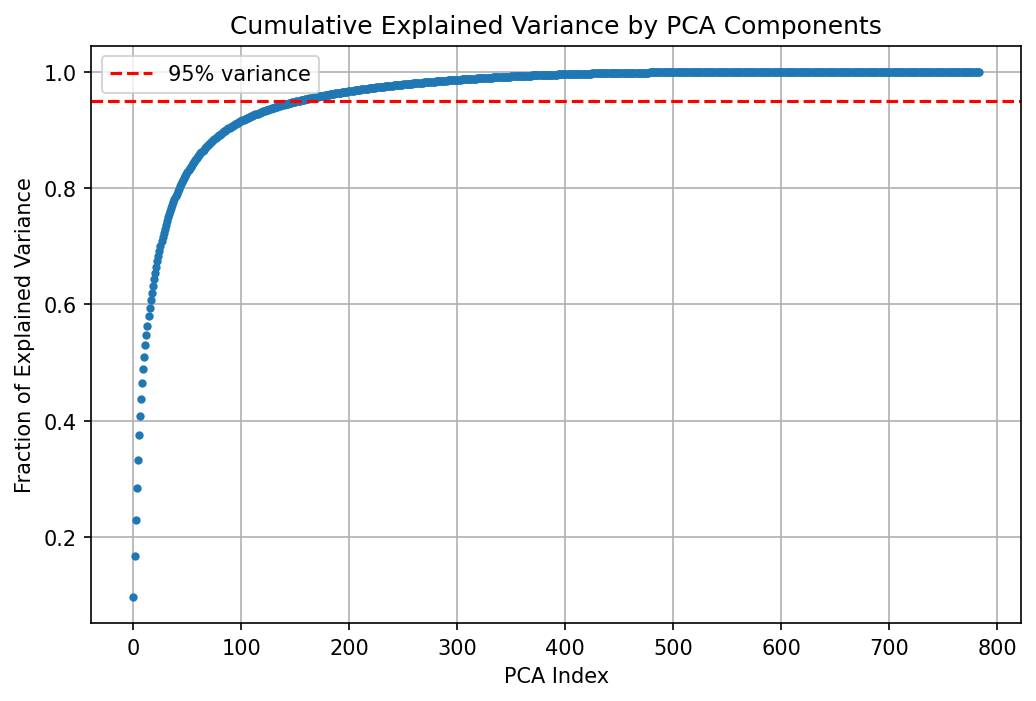

Components needed for 95% explained variance: 154


In [12]:
# plot cumulative explained variance
cumsum = np.cumsum(vals.real)
cdf = cumsum / cumsum[-1]
index = np.arange(len(vals))

plt.subplots(figsize=(8, 5))
plt.plot(index, cdf, '.')
plt.xlabel('PCA Index')
plt.ylabel('Fraction of Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.legend()
plt.grid(True)
plt.show()

# find how many components for 95% variance
n95 = np.searchsorted(cdf, 0.95) + 1
print(f"Components needed for 95% explained variance: {n95}")

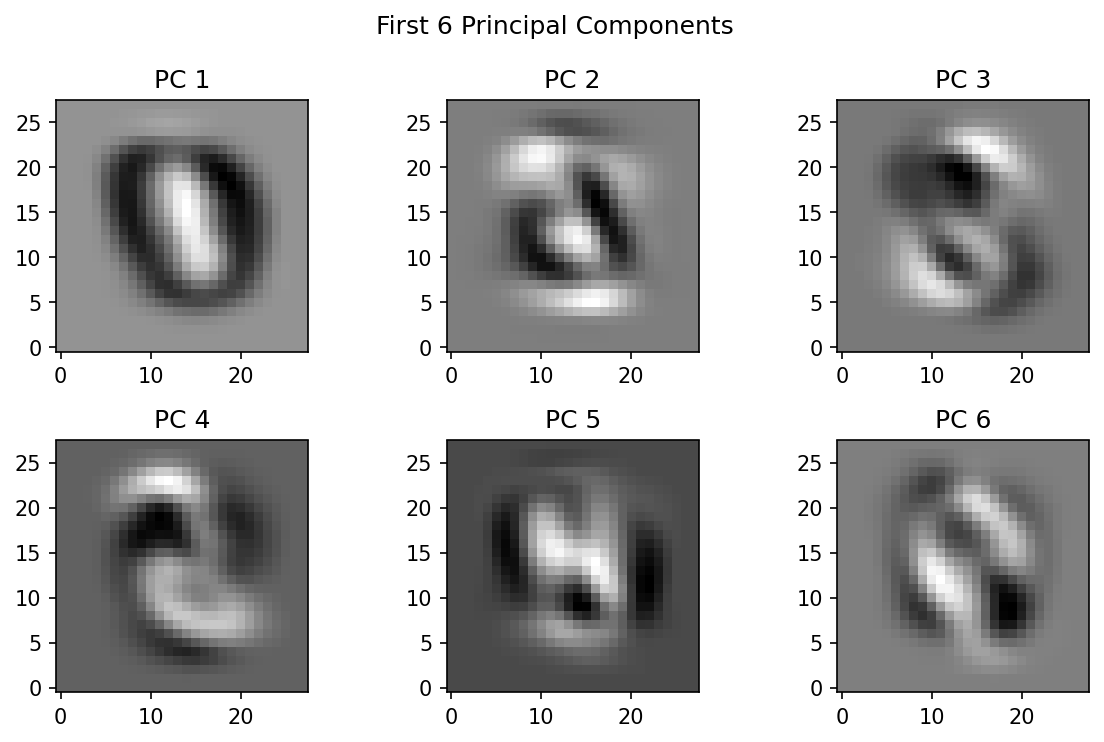

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(8, 5))
for i in range(2):
    for j in range(3):
        idx = i * 3 + j
        ax[i, j].imshow(np.reshape(vecs[:, idx], [28, 28]),
                        origin='lower', cmap='binary', interpolation='nearest')
        ax[i, j].set_title(f'PC {idx + 1}')
plt.suptitle('First 6 Principal Components')
plt.tight_layout()
plt.show()

In [14]:
def reconstruct_pca(images_flat, mu, vecs, n_components):
    """Reconstruct images using the first n_components PCA components."""
    x_centered = images_flat - mu
    P = np.dot(x_centered, vecs[:, :n_components])  # project
    x_reconstructed = np.dot(P, vecs[:, :n_components].T) + mu  # reconstruct
    return x_reconstructed

# flatten test images
X_test = np.reshape(test_images_norm, (10000, 784))

# range of N values to test
N_values = [2, 5, 10, 20, 50, 100, 200, 300, 500, 784]
accuracies_step3 = []

for N in N_values:
    # reconstruct test images using N PCA components
    X_test_recon = reconstruct_pca(X_test, mu, vecs, N)
    # reshape back to (10000, 28, 28) for the network
    test_recon_images = np.reshape(X_test_recon, (10000, 28, 28))
    # evaluate the Step 1 model (no retraining)
    loss, acc = model_full.evaluate(test_recon_images, test_labels, verbose=0)
    accuracies_step3.append(acc)
    print(f"N = {N:>4d} PCA components -> Test Accuracy = {acc:.4f}")

N =    2 PCA components -> Test Accuracy = 0.3648
N =    5 PCA components -> Test Accuracy = 0.6321
N =   10 PCA components -> Test Accuracy = 0.8346
N =   20 PCA components -> Test Accuracy = 0.9153
N =   50 PCA components -> Test Accuracy = 0.9468
N =  100 PCA components -> Test Accuracy = 0.9502
N =  200 PCA components -> Test Accuracy = 0.9510
N =  300 PCA components -> Test Accuracy = 0.9510
N =  500 PCA components -> Test Accuracy = 0.9509
N =  784 PCA components -> Test Accuracy = 0.9509


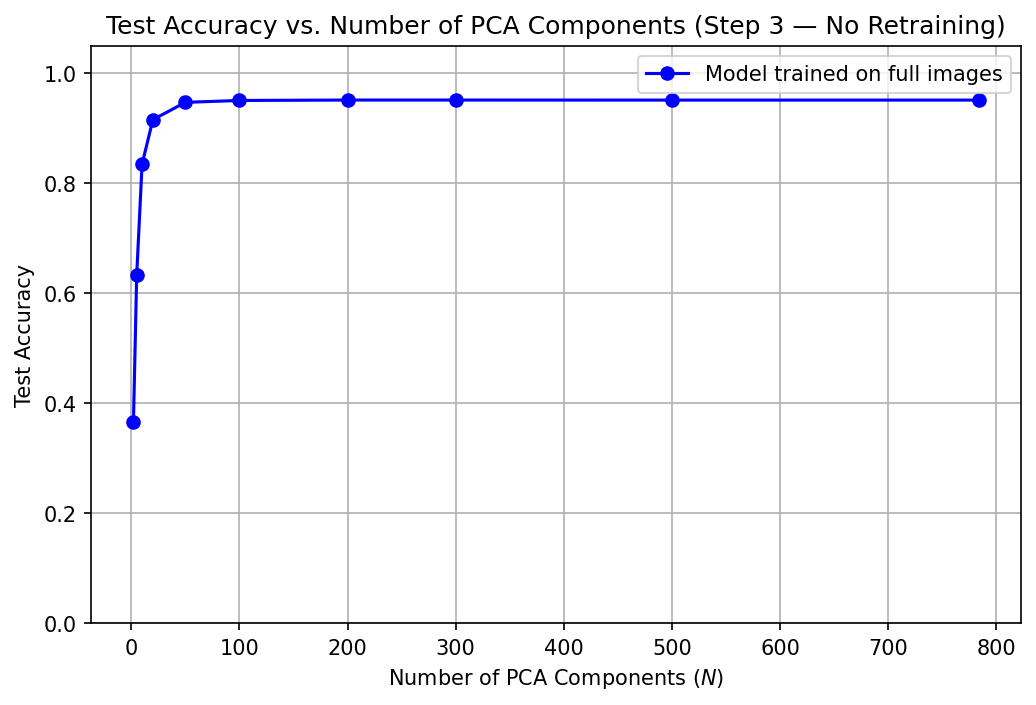

In [15]:
# plot N vs testing accuracy
plt.figure(figsize=(8, 5))
plt.plot(N_values, accuracies_step3, marker='o', linestyle='-', color='b',
         label='Model trained on full images')
plt.title('Test Accuracy vs. Number of PCA Components (Step 3 — No Retraining)')
plt.xlabel('Number of PCA Components ($N$)')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.ylim(0, 1.05)
plt.legend()
plt.show()

In [16]:
# reconstruct training images using 100 PCA components
N_pca_train = 100
X_train_recon_100 = reconstruct_pca(X_train, mu, vecs, N_pca_train)
train_recon_100 = np.reshape(X_train_recon_100, (60000, 28, 28))

# retrain the model on PCA-100 reconstructed training data
model_pca100, history_pca100 = build_and_train_model(
    train_recon_100, train_labels, epochs=20
)

# quick check on clean test data
loss, acc = model_pca100.evaluate(test_images_norm, test_labels, verbose=0)
print(f"\nStep 4 — Model (PCA-100 trained) on clean test data: {acc:.4f}")

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6557 - loss: 1.3529 - val_accuracy: 0.9022 - val_loss: 0.4209
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8822 - loss: 0.4666 - val_accuracy: 0.9197 - val_loss: 0.3193
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8944 - loss: 0.3864 - val_accuracy: 0.9267 - val_loss: 0.2829
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9040 - loss: 0.3408 - val_accuracy: 0.9295 - val_loss: 0.2608
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9109 - loss: 0.3206 - val_accuracy: 0.9327 - val_loss: 0.2453
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9177 - loss: 0.2935 - val_accuracy: 0.9388 - val_loss: 0.2315
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9216 - loss: 0.2802 - val_accuracy: 0.9403 - val_loss: 0.2203
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9262 - loss: 0.2672 - val_accuracy: 0.

---
## Step 5: Evaluate PCA-100 Network on PCA-Reconstructed Test Data

Same procedure as Step 3, but now using the network retrained in Step 4 on PCA-100 data. We expect this model to perform better at lower $N$ values since it was trained on PCA-compressed data and has adapted to the information loss.

In [17]:
accuracies_step5 = []

for N in N_values:
    # reconstruct test images using N PCA components
    X_test_recon = reconstruct_pca(X_test, mu, vecs, N)
    test_recon_images = np.reshape(X_test_recon, (10000, 28, 28))
    # evaluate the PCA-100 retrained model
    loss, acc = model_pca100.evaluate(test_recon_images, test_labels, verbose=0)
    accuracies_step5.append(acc)
    print(f"N = {N:>4d} PCA components -> Test Accuracy = {acc:.4f}")

N =    2 PCA components -> Test Accuracy = 0.3520
N =    5 PCA components -> Test Accuracy = 0.6325
N =   10 PCA components -> Test Accuracy = 0.8410
N =   20 PCA components -> Test Accuracy = 0.9202
N =   50 PCA components -> Test Accuracy = 0.9479
N =  100 PCA components -> Test Accuracy = 0.9508
N =  200 PCA components -> Test Accuracy = 0.9500
N =  300 PCA components -> Test Accuracy = 0.9506
N =  500 PCA components -> Test Accuracy = 0.9494
N =  784 PCA components -> Test Accuracy = 0.9492


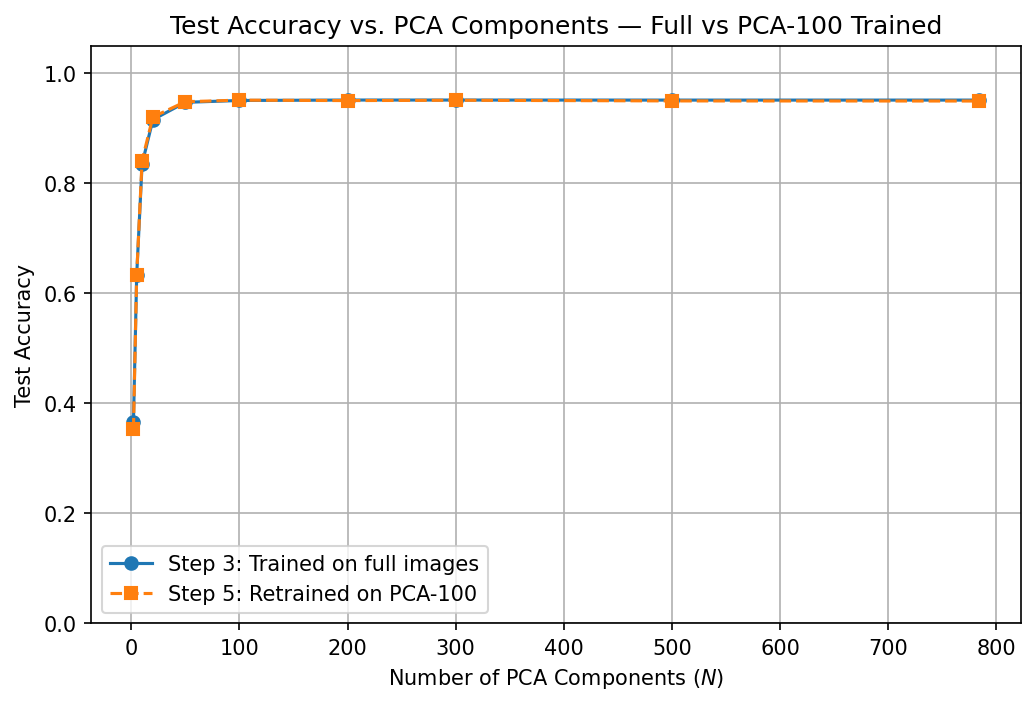

In [18]:
# plot comparison: Step 3 vs Step 5
plt.figure(figsize=(8, 5))
plt.plot(N_values, accuracies_step3, marker='o', linestyle='-',
         label='Step 3: Trained on full images')
plt.plot(N_values, accuracies_step5, marker='s', linestyle='--',
         label='Step 5: Retrained on PCA-100')
plt.title('Test Accuracy vs. PCA Components — Full vs PCA-100 Trained')
plt.xlabel('Number of PCA Components ($N$)')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.ylim(0, 1.05)
plt.legend()
plt.show()

---
## Step 6: Repeat Steps 4 & 5 Using 20-Best PCA Components

Now use only 20 PCA components to retrain the network and then evaluate it across the same range of $N$ values. With only 20 components the reconstructed images lose significant fine detail, but the network should learn to work with this coarser representation.

In [20]:
# reconstruct training images using 20 PCA components
N_pca_train_20 = 20
X_train_recon_20 = reconstruct_pca(X_train, mu, vecs, N_pca_train_20)
train_recon_20 = np.reshape(X_train_recon_20, (60000, 28, 28))

# retrain the model on PCA-20 reconstructed training data
model_pca20, history_pca20 = build_and_train_model(
    train_recon_20, train_labels, epochs=20
)

# quick check on clean test data
loss, acc = model_pca20.evaluate(test_images_norm, test_labels, verbose=0)
print(f"\nStep 6 — Model (PCA-20 trained) on clean test data: {acc:.4f}")

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6366 - loss: 1.3725 - val_accuracy: 0.8872 - val_loss: 0.4756
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8589 - loss: 0.5239 - val_accuracy: 0.9012 - val_loss: 0.3714
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8742 - loss: 0.4446 - val_accuracy: 0.9055 - val_loss: 0.3335
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8827 - loss: 0.4033 - val_accuracy: 0.9107 - val_loss: 0.3117
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8878 - loss: 0.3837 - val_accuracy: 0.9163 - val_loss: 0.2923
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8983 - loss: 0.3527 - val_accuracy: 0.9203 - val_loss: 0.2776
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9026 - loss: 0.3328 - val_accuracy: 0.9238 - val_loss: 0.2629
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9042 - loss: 0.3297 - val_accuracy: 0.

In [21]:
# evaluate the PCA-20 retrained model across different N values
accuracies_step6 = []

for N in N_values:
    X_test_recon = reconstruct_pca(X_test, mu, vecs, N)
    test_recon_images = np.reshape(X_test_recon, (10000, 28, 28))
    loss, acc = model_pca20.evaluate(test_recon_images, test_labels, verbose=0)
    accuracies_step6.append(acc)
    print(f"N = {N:>4d} PCA components -> Test Accuracy = {acc:.4f}")

N =    2 PCA components -> Test Accuracy = 0.3635
N =    5 PCA components -> Test Accuracy = 0.6468
N =   10 PCA components -> Test Accuracy = 0.8605
N =   20 PCA components -> Test Accuracy = 0.9421
N =   50 PCA components -> Test Accuracy = 0.9385
N =  100 PCA components -> Test Accuracy = 0.9372
N =  200 PCA components -> Test Accuracy = 0.9358
N =  300 PCA components -> Test Accuracy = 0.9351
N =  500 PCA components -> Test Accuracy = 0.9338
N =  784 PCA components -> Test Accuracy = 0.9338


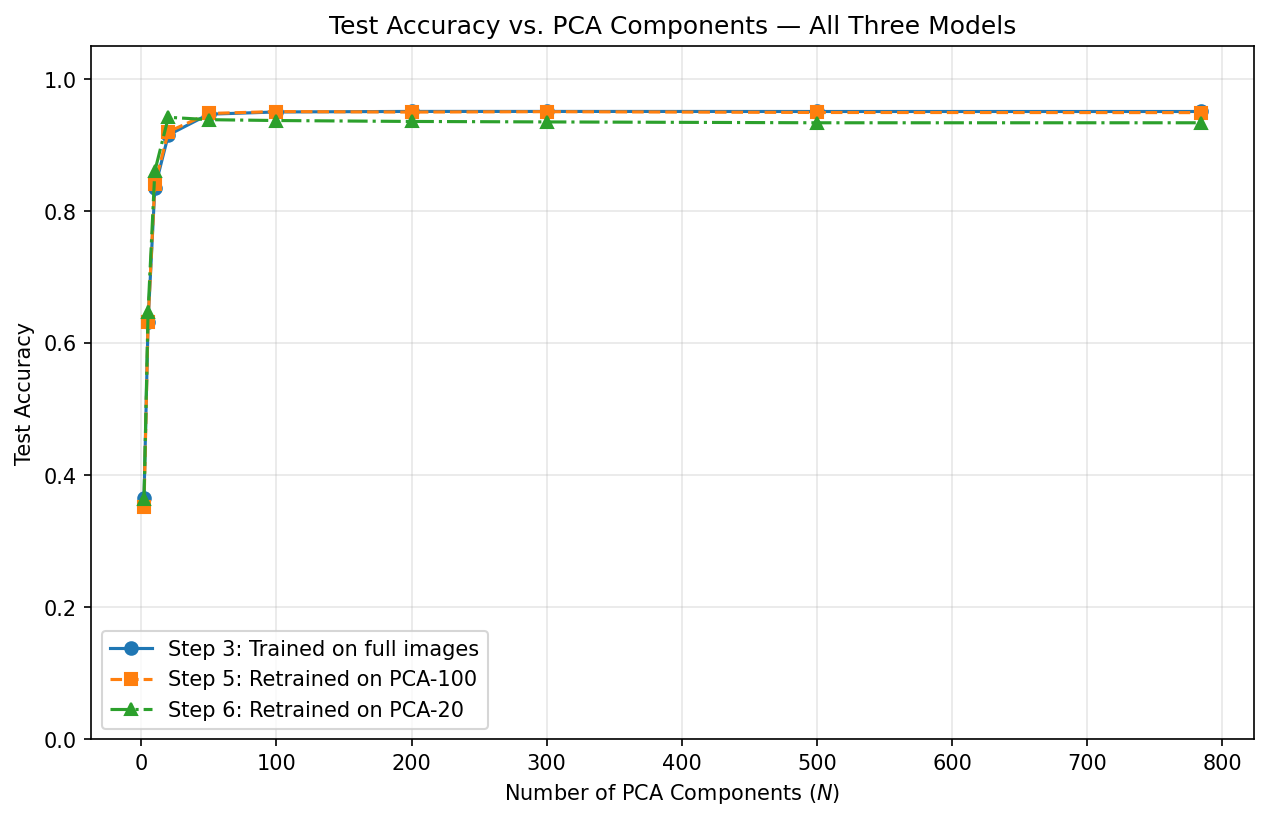

In [22]:
# final comparison plot: all three models
plt.figure(figsize=(10, 6))
plt.plot(N_values, accuracies_step3, marker='o', linestyle='-',
         label='Step 3: Trained on full images')
plt.plot(N_values, accuracies_step5, marker='s', linestyle='--',
         label='Step 5: Retrained on PCA-100')
plt.plot(N_values, accuracies_step6, marker='^', linestyle='-.',
         label='Step 6: Retrained on PCA-20')

plt.title('Test Accuracy vs. PCA Components — All Three Models')
plt.xlabel('Number of PCA Components ($N$)')
plt.ylabel('Test Accuracy')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.legend()
plt.show()